# 3.8 Assignment 3: Logistic Regression and kNN (Graded)
Updated by Steve G on 10/14/25

You will be asked to apply what you have learned so far in the module to show your understanding of logistic regression and kNN. Complete your answers in a document to be uploaded as a PDF once the assignment is complete

In [66]:
#%clear all

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import warnings
from sklearn import metrics
warnings.filterwarnings("ignore")

1. Create a logistics regression model to predict the class label from the first eight attributes of the question set.
2. Try doing the same using two different subsets (your choice) of those eight attributes.
3. Report the accuracies of each of these three models.
4. For the two subsets that you use, provide some justification (why you chose those features in a given subset).

## Problem-1:

An automated answer-rating site marks each post in a community forum website as “good” or “bad” based on the quality of the post. The CSV file, which you can download here, contains the various types of quality as measured by the tool. Following are the type of qualities that the dataset contains:

i. num_words: number of words in the post  
ii. num_characters: number of characters in the post  
iii. num_misspelled: number of misspelled words  
iv. bin_end_qmark: if the post ends with a question mark  
v. num_interrogative: number of interrogative words in the post  
vi. bin_start_small: if the answer starts with a lowercase letter. (‘1’ means yes, otherwise no)  
vii. num_sentences: number of sentences per post  
viii. num_punctuations: number of punctuation symbols in the post  
ix. label: the label of the post (‘G’ for good and ‘B’ for bad) as determined by the tool.  

Create a logistics regression model to predict the class label from the first eight attributes of the question set.  Then try doing the same using two different subsets of those eight attributes. Report the accuracies of each of these three models. [5 points]


In [68]:
df_quality = pd.read_csv("quality.csv")
df_quality.head()

,S.No.,num_words,num_characters,num_misspelled,bin_end_qmark,num_interrogative,bin_start_small,num_sentences,num_punctuations,label
0,1,10,48,2,0,0,0,2,4,B
1,2,8,25,0,0,0,1,1,0,B
2,3,20,81,0,1,19,0,1,1,B
3,4,9,34,1,0,1,0,1,2,B
4,5,18,69,3,0,1,0,1,0,B


In [69]:
df = pd.read_csv("quality.csv")
df['result_label'] = np.where(df['label'] =='G',1,0)
result_labels = df['result_label']
df1 = df
df1 =df1.drop(columns = ['result_label','label'])
print(df1.shape)
df1.head()

(28, 9)


,S.No.,num_words,num_characters,num_misspelled,bin_end_qmark,num_interrogative,bin_start_small,num_sentences,num_punctuations
0,1,10,48,2,0,0,0,2,4
1,2,8,25,0,0,0,1,1,0
2,3,20,81,0,1,19,0,1,1
3,4,9,34,1,0,1,0,1,2
4,5,18,69,3,0,1,0,1,0


In [70]:
X_trn,X_tst,y_trn,y_tst = train_test_split(df1,result_labels, test_size =0.2)
clf1 = LogisticRegression()
clf1.fit(X_trn,y_trn)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
y_pred = clf1.predict(X_tst)
y_pred_train = clf1.predict(X_trn)
accuracy1 = metrics.accuracy_score(y_tst,y_pred)
accuracy2 = metrics.accuracy_score(y_trn,y_pred_train)
print('Accuracy', accuracy2)
print('Shape', df_quality.shape)

Accuracy 1.0
Shape (28, 10)


### deploy logistic regression models

In [73]:
def manipulate_logit_func(X, y, iterations):
    """Each iteration creates a new random train/test split of the data using train_test_split. This means the model is trained and evaluated on different subsets of the data each time, so the accuracy and metrics can vary between iterations. This helps assess the model's stability and average performance across different data splits."""
    i_list = []
    acc_record = []
    for i in range(iterations):
        # Creating X and Y for training and testing
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
        # Creating Logisitic Regression model
        model = LogisticRegression()
        model.fit(X_train,y_train)
        # Predicting on Test set
        predictions = model.predict(X_test)
        accuracy = accuracy_score(y_test,predictions)
        print("iteration:", i)
        print(accuracy)
        print(confusion_matrix(y_test,predictions))
        print(classification_report(y_test, predictions))
        i_list.append(i)
        acc_record.append(accuracy)
    return(i_list, acc_record)
i_list, acc_record = manipulate_logit_func(X, y, 100)

#### Q1 - First eight attributes

In [74]:
X = df_quality.iloc[:,1:9]
#y = df_quality.iloc[:,-1]
y = np.where(df_quality['label'] == 'B', 0, 1)
i_list, acc_record = manipulate_logit_func(X, y, 100)

iteration: 0
0.6666666666666666
[[2 1]
 [2 4]]
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.80      0.67      0.73         6

    accuracy                           0.67         9
   macro avg       0.65      0.67      0.65         9
weighted avg       0.70      0.67      0.68         9

iteration: 1
0.5555555555555556
[[1 4]
 [0 4]]
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.50      1.00      0.67         4

    accuracy                           0.56         9
   macro avg       0.75      0.60      0.50         9
weighted avg       0.78      0.56      0.48         9

iteration: 2
0.6666666666666666
[[3 0]
 [3 3]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         3
           1       1.00      0.50      0.67         6

    accuracy                           0.

average accuracy: 0.6466666666666666


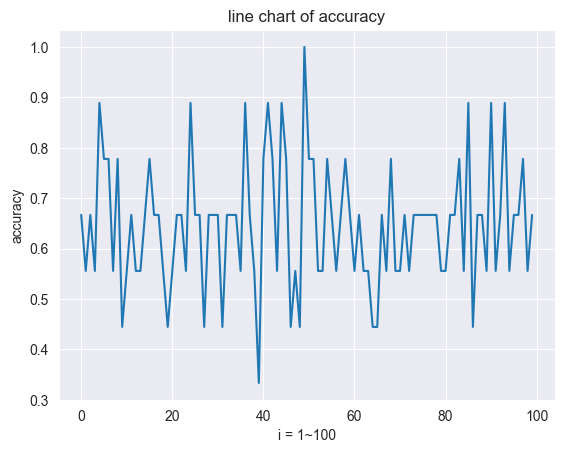

In [75]:
# Plot of accuracy
plt.plot(i_list, acc_record)
#plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.0])
plt.xlabel('i = 1~100')
plt.ylabel('accuracy')
plt.title('line chart of accuracy')
print("average accuracy:", sum(acc_record) / len(acc_record) )

Text(0.5, 1.0, 'line chart of accuracy')

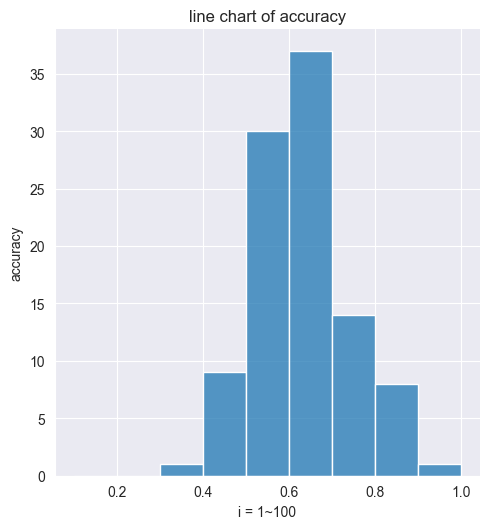

In [76]:
sns.displot(acc_record, 
            bins=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
plt.xlabel('i = 1~100')
plt.ylabel('accuracy')
plt.title('line chart of accuracy')

#### model 2&3 - the subset of first eight attributes

In [77]:
X = df_quality.iloc[:,[2,5,6]]
y = df_quality.iloc[:,-1]

i_list, acc_record = manipulate_logit_func(X, y, 100)

iteration: 0
0.5555555555555556
[[3 2]
 [2 2]]
              precision    recall  f1-score   support

           B       0.60      0.60      0.60         5
           G       0.50      0.50      0.50         4

    accuracy                           0.56         9
   macro avg       0.55      0.55      0.55         9
weighted avg       0.56      0.56      0.56         9

iteration: 1
0.7777777777777778
[[4 1]
 [1 3]]
              precision    recall  f1-score   support

           B       0.80      0.80      0.80         5
           G       0.75      0.75      0.75         4

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9

iteration: 2
0.5555555555555556
[[2 3]
 [1 3]]
              precision    recall  f1-score   support

           B       0.67      0.40      0.50         5
           G       0.50      0.75      0.60         4

    accuracy                           0.

<Axes: ylabel='accuracy'>

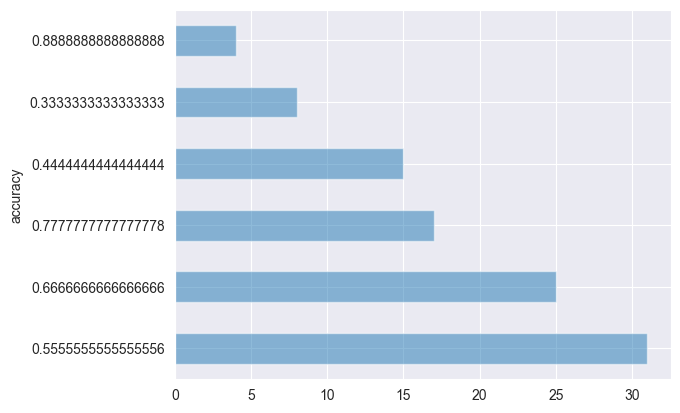

In [78]:
df = pd.DataFrame((acc_record),columns=['accuracy'])
(df['accuracy'].value_counts()).plot(kind='barh', alpha=0.5)

average accuracy: 0.6


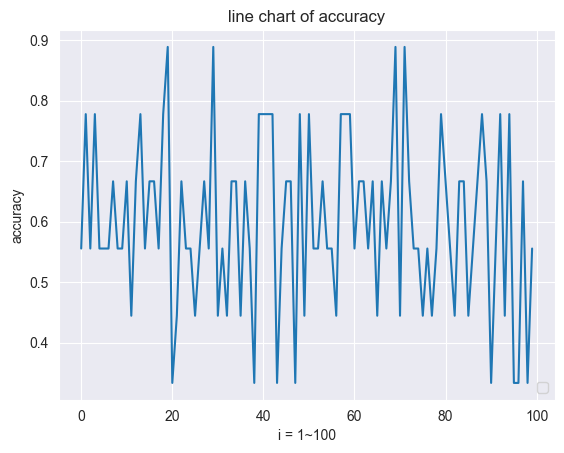

In [79]:
# Plot of accuracy
plt.plot(i_list, acc_record)
#plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.0])
plt.xlabel('i = 1~100')
plt.ylabel('accuracy')
plt.title('line chart of accuracy')
plt.legend(loc="lower right")
print("average accuracy:", sum(acc_record) / len(acc_record) )


## Problem-2:

Download the wine dataset. It contains information about a number of wines -- their characteristics (features) and if it's considered high quality or not (1 or 0). First, do some experiments (trial-and-error) to figure out a good subset of features to use for learning wine quality (last column). Report these features.

Then, use 70% data for training to build a kNN classifier with different values of k ranging from 2 to 10. Plot your accuracies with each of these. In other words, your final result will be a line chart with k on the x-axis and accuracy on the y-axis. [5 points]

### read data

In [80]:
df_wine = pd.read_csv("wine.csv")
df_wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,is_red,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1.0,0.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,1.0,0.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,1.0,0.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,1.0,0.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1.0,0.0


In [81]:
# modify data types
df_wine["high_quality"] = df_wine["high_quality"].astype(int)

#### First, do some experiments (trial-and-error) to figure out a good subset of features to use for learning wine quality (last column). Report these features.

In [82]:
df_wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,is_red,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1.0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,1.0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,1.0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,1.0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1.0,0


In [83]:
#creating labelEncoder
le = preprocessing.LabelEncoder()
# Converting string labels into numbers.
df_wine["color"] = le.fit_transform(df_wine["color"])

In [84]:
df_wine["color"]

0       0
1       0
2       0
3       0
4       0
       ..
6492    1
6493    1
6494    1
6495    1
6496    1
Name: color, Length: 6497, dtype: int64

In [85]:
df_wine.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'color', 'is_red',
       'high_quality'],
      dtype='object')

#### Then, use 70% data for training to build a kNN classifier with different values of k ranging from 2–10.

### Create a KNN Classfier model

In [86]:
#Making X and Y for training and testing
use_columns = ['fixed_acidity', 
               'volatile_acidity', 
               'citric_acid', 
               'residual_sugar',
               'chlorides', 
               'free_sulfur_dioxide', 
               'total_sulfur_dioxide', 
               'density',
               'pH', 
               'sulphates', 
               'alcohol', 
               'quality',
               'color',
               'is_red'
              ]

X = df_wine[use_columns]
y = df_wine["high_quality"]

#Normalizing the data 
X_normalized = X.apply(lambda x: (x -min(x))/(max(x)-min(x)))

#Creating train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

k_list = []
acc_record = []
for k in range(2, 11):
    #Creating KNN Classfier model
    knn = KNeighborsClassifier(n_neighbors=k)

    #Fitting the training data
    knn.fit(X_train,y_train)

    #Predicting on the test data
    predictions = knn.predict(X_test)
    
    accuracy = accuracy_score(y_test,predictions)
    print("k=", k)
    #Printing Confusion matrix and accuracy socres 
    print(confusion_matrix(y_test,predictions))
    print(accuracy)
    
    k_list.append(k)
    acc_record.append(accuracy)

k= 2
[[1517   50]
 [ 238  145]]
0.8523076923076923
k= 3
[[1463  104]
 [ 184  199]]
0.8523076923076923
k= 4
[[1519   48]
 [ 253  130]]
0.8456410256410256
k= 5
[[1479   88]
 [ 212  171]]
0.8461538461538461
k= 6
[[1519   48]
 [ 277  106]]
0.8333333333333334
k= 7
[[1493   74]
 [ 243  140]]
0.8374358974358974
k= 8
[[1527   40]
 [ 285   98]]
0.8333333333333334
k= 9
[[1498   69]
 [ 266  117]]
0.8282051282051283
k= 10
[[1522   45]
 [ 296   87]]
0.8251282051282052


#### Plot your accuracies with each of these. In other words, your final result will be a line chart with k on the x-axis and accuracy on the y-axis. 

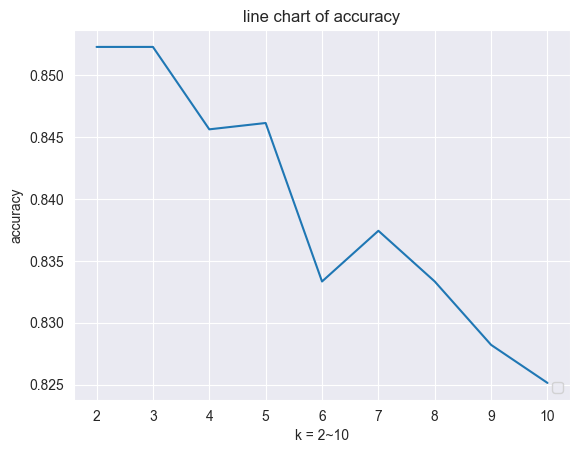

In [87]:
# Plot of accuracy
plt.plot(k_list, acc_record)
#plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.0])
plt.xlabel('k = 2~10')
plt.ylabel('accuracy')
plt.title('line chart of accuracy')
plt.legend(loc="lower right")